In [1]:
import requests
import pandas as pd
import json

url = "https://archive-api.open-meteo.com/v1/archive"

def request(params):
    req = requests.get(url, params=params)
    data = req.json()
    data_j = json.dumps(data,indent=2, ensure_ascii=False)
    return data
    return data_j

params_spb = {'latitude':59.93863, 
          'longitude':30.31413,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

params_madrid = {'latitude':40.4165, 
          'longitude':-3.70256,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

params_washington = {'latitude':38.89511, 
          'longitude':-77.03637,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

data_spb_raw = request(params_spb)
data_spb = pd.DataFrame({
    'City':'Moscow',
    'Date':data_spb_raw['daily']['time'],
    'Temp_max':data_spb_raw['daily']['temperature_2m_max'],
    'Temp_min':data_spb_raw['daily']['temperature_2m_min']
})

data_madrid_raw = request(params_madrid)
data_madrid = pd.DataFrame({
    'City':'Madrid',
    'Date':data_madrid_raw['daily']['time'],
    'Temp_max':data_madrid_raw['daily']['temperature_2m_max'],
    'Temp_min':data_madrid_raw['daily']['temperature_2m_min']
})

data_washington_raw = request(params_washington)
data_washington = pd.DataFrame({
    'City':'Washington',
    'Date':data_washington_raw['daily']['time'],
    'Temp_max':data_washington_raw['daily']['temperature_2m_max'],
    'Temp_min':data_washington_raw['daily']['temperature_2m_min']
})

data_united = pd.concat([data_spb, data_madrid, data_washington])

print(data_united)

          City        Date  Temp_max  Temp_min
0       Moscow  2025-08-01      27.4      18.0
1       Moscow  2025-08-02      22.2      17.2
2       Moscow  2025-08-03      25.9      15.1
3       Moscow  2025-08-04      27.5      16.7
4       Moscow  2025-08-05      25.6      16.9
..         ...         ...       ...       ...
27  Washington  2025-08-28      25.9      14.8
28  Washington  2025-08-29      25.8      16.8
29  Washington  2025-08-30      24.5      13.6
30  Washington  2025-08-31      26.3      14.4
31  Washington  2025-09-01      25.9      15.3

[96 rows x 4 columns]


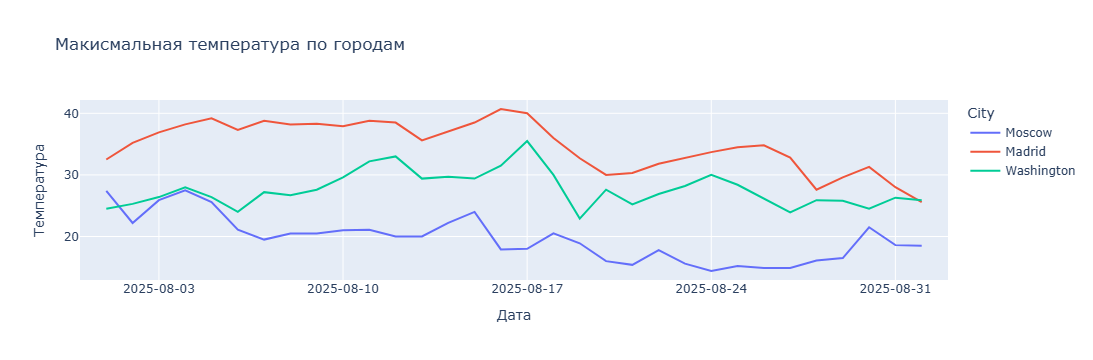

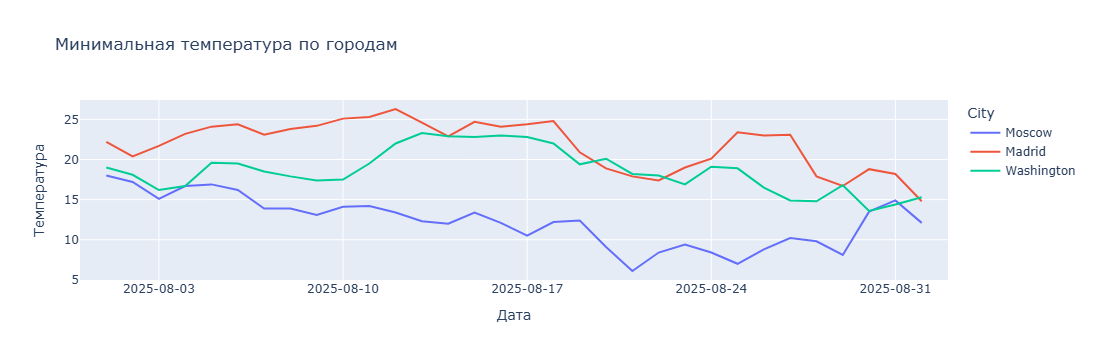

In [3]:
import plotly.express as px
import matplotlib.pyplot as plt

fig_max = px.line(data_united, x='Date', y='Temp_max', color='City',
                  title='Макисмальная температура по городам',
                  labels={'Date':'Дата', 'Temp_max':'Температура'})

fig_min = px.line(data_united, x='Date', y='Temp_min', color='City',
                  title='Минимальная температура по городам',
                  labels={'Date':'Дата', 'Temp_min':'Температура'})

fig_max.update_xaxes(tickformat='%Y-%m-%d', range=['2025-07-31','2025-09-02'])
fig_min.update_xaxes(tickformat='%Y-%m-%d', range=['2025-07-31','2025-09-02'])

fig_max.show()
fig_min.show()

In [6]:
import requests
from bs4 import BeautifulSoup as bs
import json

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36'}
url = 'https://ru.wikipedia.org/wiki/Список_стран_по_ВВП_(номинал)'

def parse_table(table):
    
    rows = table.find_all('tr')
    headers = [th.text.strip() for th in table.find_all('th')]
    
    if not headers:
        first_row = rows[0]
        if first_row:
            headers = [f'col_{i}' for i in range(len(first_row.find_all(['td', 'th'])))]

    data = []
    for row in rows:
        cells = row.find_all('td')
        if cells:
            first_cell = cells[0].text.strip()
            if first_cell and first_cell.isdigit():
                row_data ={}
                for i, cell in enumerate(cells):
                    if i < len(headers):
                        row_data[headers[i]] = cell.text.strip()
                data.append(row_data)
    return data
    
req = requests.get(url, headers=headers)
soup = bs(req.text, 'html.parser')
table = soup.find('table', {'id':'mwLg'})
data = parse_table(table)
print(json.dumps(data, indent=2, ensure_ascii=False))

[
  {
    "№": "1",
    "Страна[a]": "США",
    "ВВП,$млн[b]": "30 615 743"
  },
  {
    "№": "2",
    "Страна[a]": "Китай",
    "ВВП,$млн[b]": "19 398 577"
  },
  {
    "№": "3",
    "Страна[a]": "Германия",
    "ВВП,$млн[b]": "5 013 574"
  },
  {
    "№": "4",
    "Страна[a]": "Япония",
    "ВВП,$млн[b]": "4 279 828"
  },
  {
    "№": "5",
    "Страна[a]": "Индия",
    "ВВП,$млн[b]": "4 125 213"
  },
  {
    "№": "6",
    "Страна[a]": "Великобритания",
    "ВВП,$млн[b]": "3 958 780"
  },
  {
    "№": "7",
    "Страна[a]": "Франция",
    "ВВП,$млн[b]": "3 361 557"
  },
  {
    "№": "8",
    "Страна[a]": "Италия",
    "ВВП,$млн[b]": "2 543 677"
  },
  {
    "№": "9",
    "Страна[a]": "Россия",
    "ВВП,$млн[b]": "2 540 656"
  },
  {
    "№": "10",
    "Страна[a]": "Канада",
    "ВВП,$млн[b]": "2 283 599"
  },
  {
    "№": "11",
    "Страна[a]": "Бразилия",
    "ВВП,$млн[b]": "2 256 910"
  },
  {
    "№": "12",
    "Страна[a]": "Испания",
    "ВВП,$млн[b]": "1 891 371"
  },
  {
    "№":

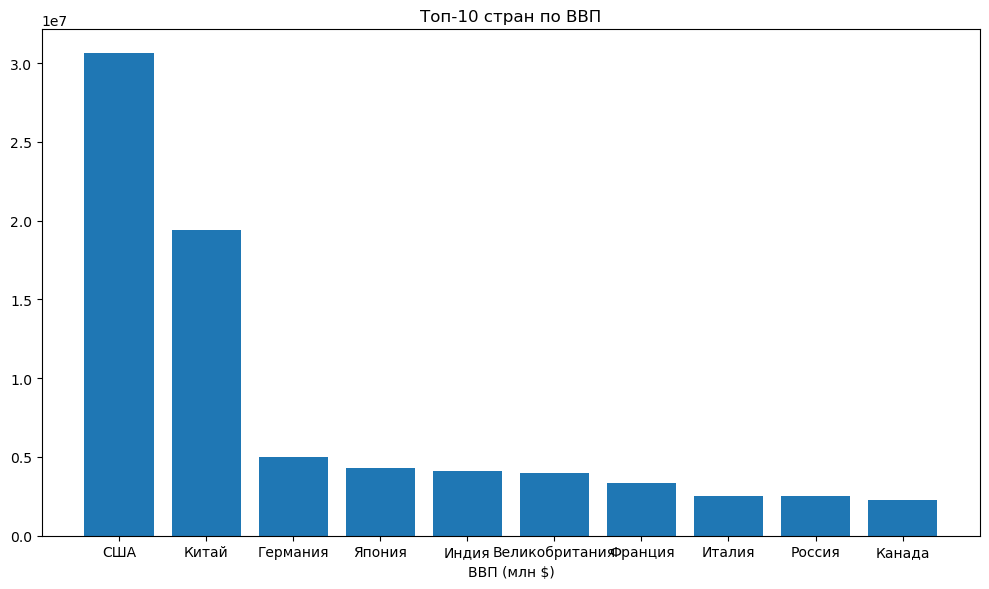

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(data)
df['ВВП,$млн[b]'] = df['ВВП,$млн[b]'].str.replace('\D', '', regex=True).astype(int)
top_10 = df.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10['Страна[a]'], top_10['ВВП,$млн[b]'])
plt.xlabel('ВВП (млн $)')
plt.title('Топ-10 стран по ВВП')
plt.tight_layout()
plt.show()